In [1]:
# ============================================================
# MODULE 3: SYNTHETIC DATASET GENERATOR
# Thesis: Predictive Optimization for Fleet Routing
# ============================================================
# WHAT THIS DOES:
#   Generates a realistic synthetic dataset of vehicle trips
#   for an engineering firm fleet. Each row = one trip between
#   two job sites with 6 features and 1 target (travel time).
#
# FEATURES (inputs to the ML model):
#   1. distance_km        — straight-line distance between nodes
#   2. time_of_day        — hour of departure (0-23)
#   3. traffic_factor     — congestion multiplier (1.0 = free flow)
#   4. road_type          — urban=0, suburban=1, highway=2
#   5. vehicle_load_pct   — % of vehicle capacity loaded (0-100)
#   6. weather_condition  — clear=0, rain=1, fog=2, storm=3
#


# PROBLEM SIZES:
#   Small  — 11 nodes  
#   Medium — 25 nodes  
#   Large  — 50 nodes  
# ============================================================

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os


In [3]:
# ------------------------------------------------------------
# STEP 1: RANDOM SEED FOR REPRODUCIBILITY
# ------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
# ------------------------------------------------------------
# STEP 2: GENERATE NODE COORDINATES FOR EACH PROBLEM SIZE
# ------------------------------------------------------------
def generate_coordinates(n_sites, grid_size=50):
    """
    Generates random (x, y) coordinates for job sites on a grid_size x grid_size km area.
    Node 0 is always the depot at the centre.
    """
    coords = [(grid_size / 2, grid_size / 2)]  # depot at centre
    while len(coords) < n_sites + 1:
        x = np.random.uniform(1, grid_size - 1)
        y = np.random.uniform(1, grid_size - 1)
        coords.append((round(x, 2), round(y, 2)))
    return coords

In [5]:
# ------------------------------------------------------------
# STEP 3: TRAFFIC FACTOR BASED ON TIME OF DAY
# ------------------------------------------------------------
def get_traffic_factor(hour):
    """
    Simulates realistic traffic patterns for an engineering firm:
    - Morning rush (7-9am): high congestion
    - Midday (10am-3pm): normal flow
    - Evening rush (4-6pm): high congestion
    - Night/early morning: very low traffic

    Returns a multiplier: 1.0 = free flow, 1.8 = heavy congestion
    """
    if 7 <= hour <= 9:       # morning rush hour
        base = 1.5
    elif 16 <= hour <= 18:   # evening rush hour
        base = 1.6
    elif 10 <= hour <= 15:   # midday — relatively free
        base = 1.0
    elif 6 <= hour <= 6:     # early morning departure
        base = 1.1
    else:                    # night / very early
        base = 0.8

    # Add realistic random noise around the base
    noise = np.random.uniform(-0.15, 0.15)
    return round(max(0.7, base +noise), 2)

In [6]:
# ------------------------------------------------------------
# STEP 4: WEATHER MULTIPLIER
# ------------------------------------------------------------
def get_weather_multiplier(weather_code):
    """
    Returns a travel time multiplier based on weather.

    weather code is 0,1,2,3 as shown below:
    clear=0  → no impact (1.0x)
    rain=1   → moderate slowdown (1.15-1.25x)
    fog=2    → significant slowdown (1.25-1.4x)
    storm=3  → severe slowdown (1.4-1.6x)
    """
    multipliers = {
        0: np.random.uniform(0.98, 1.02),   # clear — minimal variation
        1: np.random.uniform(1.15, 1.25),   # rain
        2: np.random.uniform(1.25, 1.40),   # fog
        3: np.random.uniform(1.40, 1.60),   # storm
    }
    return multipliers[weather_code]

In [7]:
# ------------------------------------------------------------
# STEP 5: VEHICLE LOAD MULTIPLIER
# ------------------------------------------------------------
def get_load_multiplier(load_pct):
    """
    Returns a travel time multiplier based on vehicle load.

    load_pct=0   → 1.0x (empty vehicle, fastest)
    load_pct=100 → 1.15x (full load, slowest)
    Linear relationship with small random noise.
    """
    base_multiplier = 1.0 + (load_pct / 100) * 0.15
    noise = np.random.uniform(-0.02, 0.02)
    return round(base_multiplier + noise, 3)

In [8]:
# ------------------------------------------------------------
# STEP 6: ROAD TYPE SPEED FACTOR
# ------------------------------------------------------------
def get_road_speed_factor(road_type):
    """
    Returns an average speed (km/min) for each road type.
    Urban roads are slowest, highways fastest per km.

    urban=0    → ~30 km/h = 0.5 km/min
    suburban=1 → ~60 km/h = 1.0 km/min
    highway=2  → ~100 km/h = 1.67 km/min
    """
    speeds = {
        0: np.random.uniform(0.40, 0.55),   # urban (km/min)
        1: np.random.uniform(0.85, 1.10),   # suburban
        2: np.random.uniform(1.50, 1.80),   # highway
    }
    return speeds[road_type]


In [9]:
# ------------------------------------------------------------
# STEP 7: COMPUTE REALISTIC TRAVEL TIME
# ------------------------------------------------------------
def compute_travel_time(distance_km, hour, road_type,vehicle_load_pct, weather_code):
    """
    Combines all factors into a realistic travel time (minutes).

    Formula:
      base_time     = distance / road_speed
      adjusted_time = base_time × traffic_factor × weather_multiplier × load_multiplier + random_noise

    """
    traffic  = get_traffic_factor(hour)
    weather  = get_weather_multiplier(weather_code)
    load     = get_load_multiplier(vehicle_load_pct)
    speed    = get_road_speed_factor(road_type)

    base_time    = distance_km / speed           # minutes
    adjusted     = base_time * traffic * weather * load
    noise        = np.random.normal(0, adjusted * 0.05)  # 5% noise
    travel_time  = max(1.0, adjusted + noise)    # at least 1 minute

    return round(travel_time, 2)

In [10]:
# ------------------------------------------------------------
# STEP 8: GENERATE DATASET FOR ONE PROBLEM SIZE
# ------------------------------------------------------------
def generate_dataset(n_sites, n_trips=3000, label=""):
    """
    Generates n_trips synthetic trip records for a problem with n_sites job sites (plus 1 depot).

    Each trip is between two randomly chosen distinct nodes.
    Features and travel time are computed realistically.

    n_trips=3000 gives enough data for robust ML training
    while keeping generation fast.
    """
    print(f"\n  Generating {label} dataset " + f"({n_sites} sites, {n_trips} trips)...")

    coords = generate_coordinates(n_sites)
    records = []

   
    weather_weights = [0.55, 0.25, 0.12, 0.08]  # clear, rain, fog, storm

    for _ in range(n_trips):
        # Pick two distinct random nodes
        i = np.random.randint(0, n_sites + 1)
        j = np.random.randint(0, n_sites + 1)
        while j == i:
            j = np.random.randint(0, n_sites + 1)

        # Compute Euclidean distance (in km — grid is in km)
        x1, y1 = coords[i]
        x2, y2 = coords[j]
        distance_km = round(math.hypot(x2 - x1, y2 - y1), 2)

        # Sample feature values
        hour             = np.random.randint(6, 20)  # 6am to 8pm
        road_type        = np.random.choice([0, 1, 2], p=[0.4, 0.35, 0.25])
        vehicle_load_pct = round(np.random.uniform(0, 100), 1)
        weather_code     = np.random.choice([0, 1, 2, 3],
                                            p=weather_weights)

        # Compute target
        travel_time = compute_travel_time
        (
            distance_km, hour, road_type,
            vehicle_load_pct, weather_code
        )

        records.append({
            "from_node":         i,
            "to_node":           j,
            "distance_km":       distance_km,
            "time_of_day":       hour,
            "traffic_factor":    get_traffic_factor(hour),
            "road_type":         road_type,
            "vehicle_load_pct":  vehicle_load_pct,
            "weather_condition": weather_code,
            "travel_time_mins":  travel_time,   # TARGET
        })

    df = pd.DataFrame(records)
    print(f"     Records   : {len(df)}")
    print(f"     Avg time  : {df['travel_time_mins'].mean():.1f} mins")
    print(f"     Max time  : {df['travel_time_mins'].max():.1f} mins")
    print(f"     Min time  : {df['travel_time_mins'].min():.1f} mins")
    return df, coords


In [11]:
# ------------------------------------------------------------
# STEP 9: EXPLORATORY DATA ANALYSIS PLOTS
# ------------------------------------------------------------
def plot_eda(df, label, output_dir):
    """
    Generates 4 EDA plots to understand the dataset.
    These plots belong in your thesis methodology chapter
    as evidence that your synthetic data is realistic.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f"Dataset EDA — {label}", fontsize=14, y=1.01)

    # Plot 1: Travel time distribution
    axes[0, 0].hist(df["travel_time_mins"], bins=50,
                    color="#7F77DD", edgecolor="white", linewidth=0.5)
    axes[0, 0].set_title("Travel time distribution")
    axes[0, 0].set_xlabel("Travel time (mins)")
    axes[0, 0].set_ylabel("Count")
    axes[0, 0].axvline(df["travel_time_mins"].mean(),
                       color="#D85A30", linestyle="--",
                       label=f"Mean: {df['travel_time_mins'].mean():.1f}")
    axes[0, 0].legend(fontsize=8)

    # Plot 2: Travel time by time of day
    hourly = df.groupby("time_of_day")["travel_time_mins"].mean()
    axes[0, 1].plot(hourly.index, hourly.values,
                    color="#1D9E75", linewidth=2, marker="o", markersize=4)
    axes[0, 1].set_title("Avg travel time by hour of day")
    axes[0, 1].set_xlabel("Hour (6am = 6, 8pm = 20)")
    axes[0, 1].set_ylabel("Avg travel time (mins)")
    axes[0, 1].axvspan(7, 9, alpha=0.15, color="red", label="Rush hour")
    axes[0, 1].axvspan(16, 18, alpha=0.15, color="red")
    axes[0, 1].legend(fontsize=8)

    # Plot 3: Travel time by weather condition
    weather_labels = ["Clear", "Rain", "Fog", "Storm"]
    weather_means  = [
        df[df["weather_condition"] == w]["travel_time_mins"].mean()
        for w in range(4)
    ]
    colors = ["#4CAF50", "#2196F3", "#9E9E9E", "#F44336"]
    axes[1, 0].bar(weather_labels, weather_means, color=colors,
                   edgecolor="white", linewidth=0.5)
    axes[1, 0].set_title("Avg travel time by weather")
    axes[1, 0].set_xlabel("Weather condition")
    axes[1, 0].set_ylabel("Avg travel time (mins)")

    # Plot 4: Distance vs travel time (coloured by road type)
    road_colors = {0: "#FF5722", 1: "#FF9800", 2: "#2196F3"}
    road_labels = {0: "Urban", 1: "Suburban", 2: "Highway"}
    for rt in [0, 1, 2]:
        subset = df[df["road_type"] == rt].sample(
            min(300, len(df[df["road_type"] == rt]))
        )
        axes[1, 1].scatter(
            subset["distance_km"],
            subset["travel_time_mins"],
            alpha=0.4, s=12,
            color=road_colors[rt],
            label=road_labels[rt]
        )
    axes[1, 1].set_title("Distance vs travel time by road type")
    axes[1, 1].set_xlabel("Distance (km)")
    axes[1, 1].set_ylabel("Travel time (mins)")
    axes[1, 1].legend(fontsize=8)

    plt.tight_layout()
    path = os.path.join(output_dir, f"eda_{label.lower().replace(' ', '_')}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"     EDA plots saved: {path}")
    plt.show()

In [12]:
# ------------------------------------------------------------
# STEP 10: SAVE DATASET
# ------------------------------------------------------------
def save_dataset(df, label, output_dir):
    """Saves the dataset as a CSV file."""
    filename = f"dataset_{label.lower().replace(' ', '_')}.csv"
    path     = os.path.join(output_dir, filename)
    df.to_csv(path, index=False)
    print(f"     Dataset saved : {path}")
    return path

In [13]:
# ------------------------------------------------------------
# STEP 11: FEATURE CORRELATION SUMMARY
# ------------------------------------------------------------
def print_correlation_summary(df, label):
    """
    Prints correlation of each feature with travel time.
    """
    print(f"\n  Feature correlations with travel_time_mins ({label}):")
    print("  " + "-"*45)
    features = [
        "distance_km", "time_of_day", "traffic_factor",
        "road_type", "vehicle_load_pct", "weather_condition"
    ]
    correlations = df[features + ["travel_time_mins"]].corr()[
        "travel_time_mins"].drop("travel_time_mins")
    for feat, corr in correlations.items():
        bar   = "█" * int(abs(corr) * 20)
        sign  = "+" if corr > 0 else "-"
        print(f"  {feat:22s}  {sign}{abs(corr):.3f}  {bar}")
    print()


  MODULE 3: SYNTHETIC DATASET GENERATION
  Random seed: 42 (report in thesis)

  Generating Small  (11 nodes) dataset (11 sites, 3000 trips)...
     Records   : 3000
     Avg time  : 42.4 mins
     Max time  : 304.1 mins
     Min time  : 1.5 mins

  Feature correlations with travel_time_mins (Small  (11 nodes)):
  ---------------------------------------------
  distance_km             +0.635  ████████████
  time_of_day             -0.023  
  traffic_factor          +0.251  █████
  road_type               -0.532  ██████████
  vehicle_load_pct        +0.027  
  weather_condition       +0.171  ███

     EDA plots saved: Datasets/eda_small__(11_nodes).png


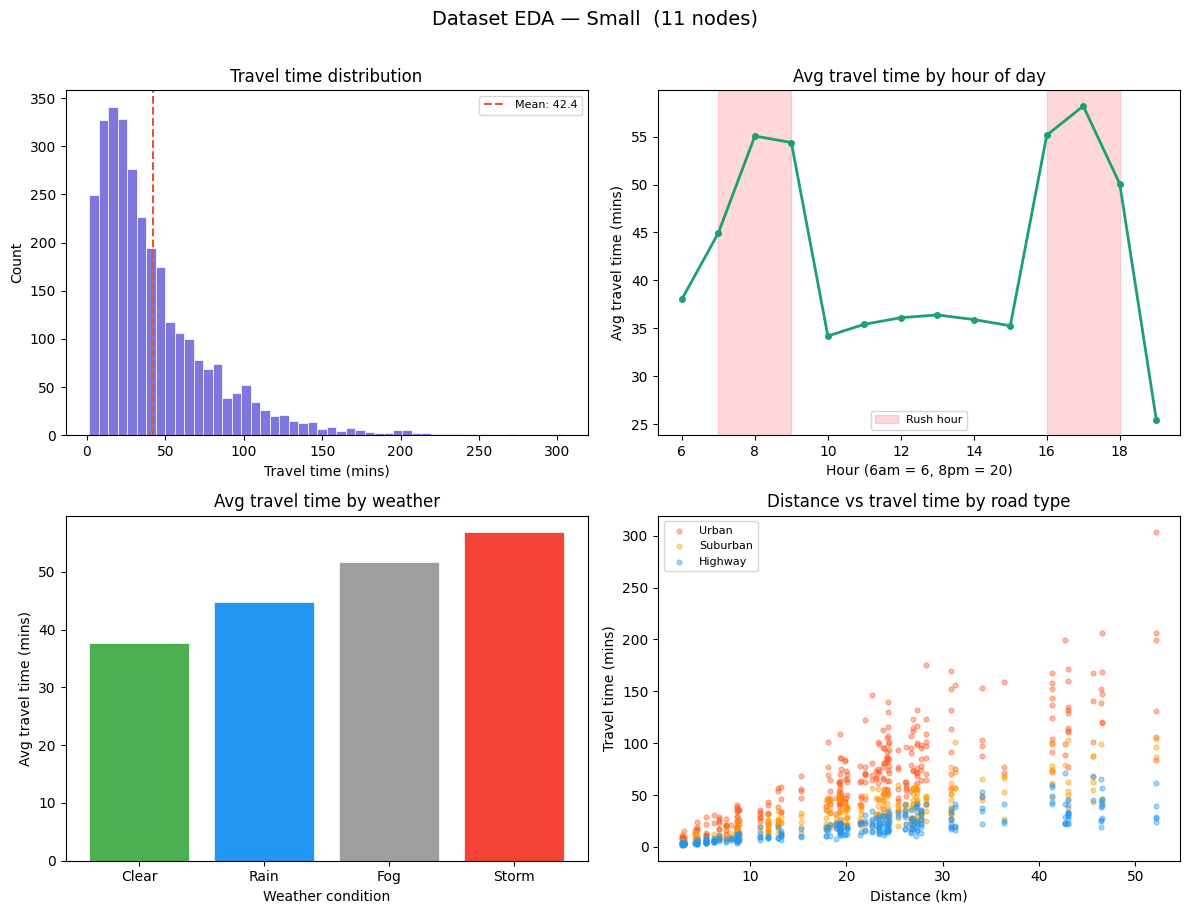

     Dataset saved : Datasets/dataset_small__(11_nodes).csv

  Generating Medium (25 nodes) dataset (25 sites, 5000 trips)...
     Records   : 5000
     Avg time  : 44.9 mins
     Max time  : 298.5 mins
     Min time  : 1.0 mins

  Feature correlations with travel_time_mins (Medium (25 nodes)):
  ---------------------------------------------
  distance_km             +0.598  ███████████
  time_of_day             -0.000  
  traffic_factor          +0.268  █████
  road_type               -0.566  ███████████
  vehicle_load_pct        +0.067  █
  weather_condition       +0.193  ███

     EDA plots saved: Datasets/eda_medium_(25_nodes).png


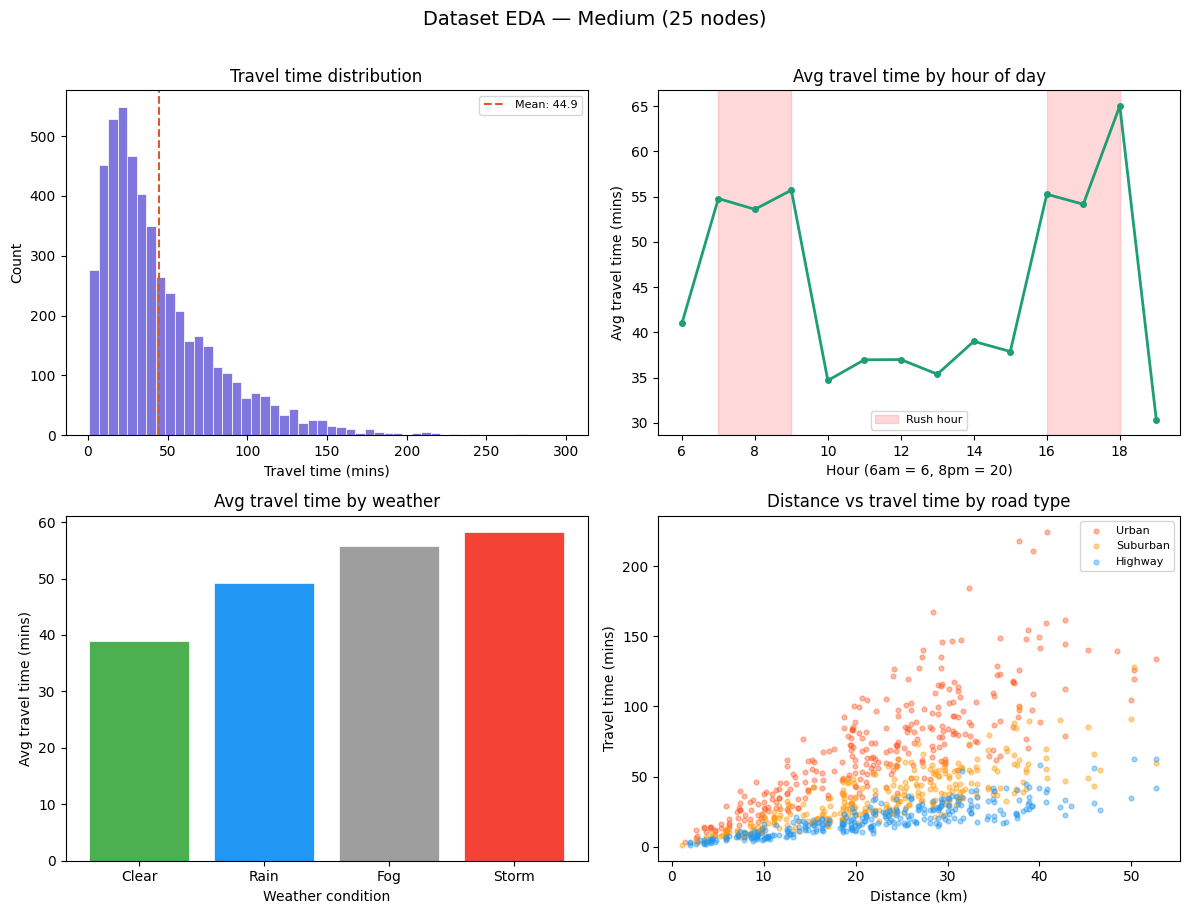

     Dataset saved : Datasets/dataset_medium_(25_nodes).csv

  Generating Large  (50 nodes) dataset (50 sites, 10000 trips)...
     Records   : 10000
     Avg time  : 51.0 mins
     Max time  : 303.0 mins
     Min time  : 1.0 mins

  Feature correlations with travel_time_mins (Large  (50 nodes)):
  ---------------------------------------------
  distance_km             +0.607  ████████████
  time_of_day             -0.015  
  traffic_factor          +0.270  █████
  road_type               -0.555  ███████████
  vehicle_load_pct        +0.069  █
  weather_condition       +0.178  ███

     EDA plots saved: Datasets/eda_large__(50_nodes).png


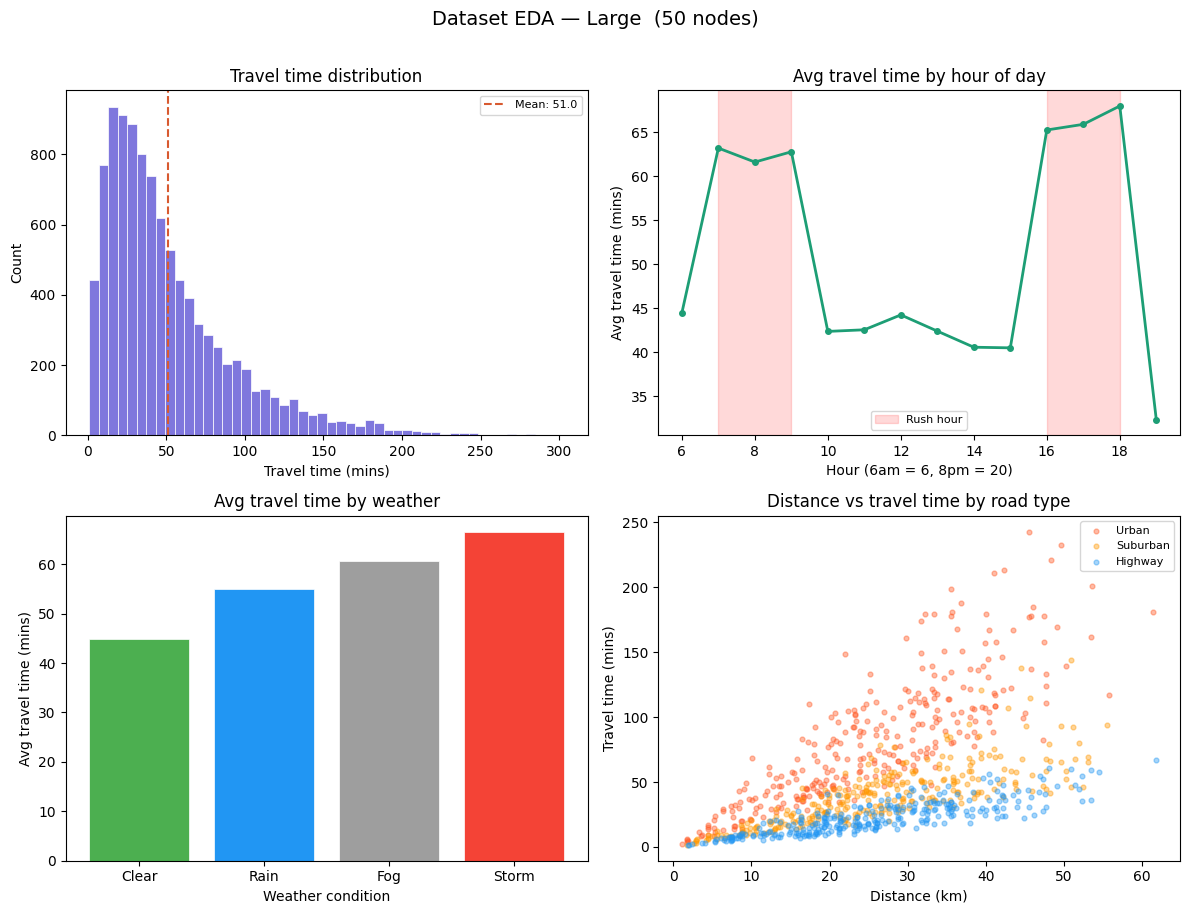

     Dataset saved : Datasets/dataset_large__(50_nodes).csv

  ALL DATASETS GENERATED SUCCESSFULLY

  Files saved:
    Datasets/dataset_small__(11_nodes).csv
    Datasets/dataset_medium_(25_nodes).csv
    Datasets/dataset_large__(50_nodes).csv

  EDA plots saved in: Datasets/


In [26]:
# ------------------------------------------------------------
# STEP 12: MAIN — GENERATE ALL THREE PROBLEM SIZES
# ------------------------------------------------------------
def main():
    output_dir = "Datasets"
    os.makedirs(output_dir, exist_ok=True)

    print("\n" + "="*55)
    print("  MODULE 3: SYNTHETIC DATASET GENERATION")
    print(f"  Random seed: {RANDOM_SEED} (report in thesis)")
    print("="*55)

    problem_sizes = [
        {"n_sites": 11,  "n_trips": 3000,  "label": "Small  (11 nodes)"},
        {"n_sites": 25,  "n_trips": 5000,  "label": "Medium (25 nodes)"},
        {"n_sites": 50,  "n_trips": 10000, "label": "Large  (50 nodes)"},
    ]

    saved_paths = []

    for config in problem_sizes:
        df, coords = generate_dataset(
            n_sites  = config["n_sites"],
            n_trips  = config["n_trips"],
            label    = config["label"]
        )
        print_correlation_summary(df, config["label"])
        plot_eda(df, config["label"], output_dir)
        path = save_dataset(df, config["label"], output_dir)
        saved_paths.append(path)

    print("\n" + "="*55)
    print("  ALL DATASETS GENERATED SUCCESSFULLY")
    print("="*55)
    print("\n  Files saved:")
    for p in saved_paths:
        print(f"    {p}")
    print(f"\n  EDA plots saved in: {output_dir}/")
    


# ------------------------------------------------------------
# ENTRY POINT
# ------------------------------------------------------------
if __name__ == "__main__":
    main()